In [2]:
# CELL 1 — Install and import the libraries required for CNN experiments

!pip install -q torch torchvision matplotlib numpy scikit-learn

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T

from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [3]:
# CELL 2 — Check whether a GPU is available for PyTorch computation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Running on CPU.")

Device: cuda
GPU: Tesla T4


In [4]:
# CELL 3 — Download and load the CIFAR-10 training and testing datasets

# Convert images to PyTorch tensors
transform = T.ToTensor()

# Load training dataset
train_dataset = CIFAR10(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# Load testing dataset
test_dataset = CIFAR10(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

100%|██████████| 170M/170M [37:46<00:00, 75.2kB/s]


Training images: 50000
Testing images: 10000


In [5]:
# CELL 4 — Define the ten CIFAR-10 class names

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Number of classes:", len(classes))
print("Classes:")

for i, class_name in enumerate(classes):
    print(i, ":", class_name)

Number of classes: 10
Classes:
0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


Image tensor shape: torch.Size([3, 32, 32])
Label: 6
Class: frog


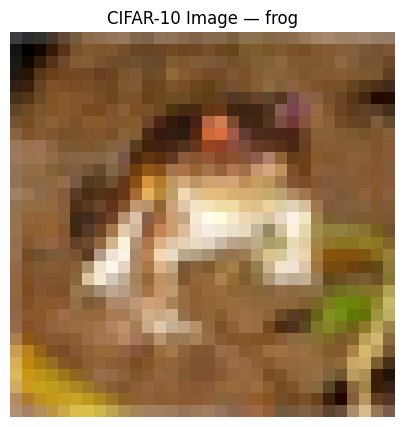

In [6]:
# CELL 5 — Display a sample CIFAR-10 image and inspect its dimensions

image, label = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Label:", label)
print("Class:", classes[label])

# Convert CHW tensor to HWC format for displaying
display_image = image.permute(1, 2, 0)

plt.figure(figsize=(5, 5))
plt.imshow(display_image)
plt.axis("off")
plt.title(f"CIFAR-10 Image — {classes[label]}")
plt.show()

In [7]:
# CELL 6 — Exercise 26: Create a learnable convolution layer

# Create a convolution layer
conv = nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3
)

# Display the shape of the learnable weights
print("Convolution weight shape:", conv.weight.shape)

# Display the shape of the bias
print("Convolution bias shape:", conv.bias.shape)

Convolution weight shape: torch.Size([8, 3, 3, 3])
Convolution bias shape: torch.Size([8])


In [8]:
# CELL 7 — Exercise 26: Inspect the values of the learnable convolution filters

print("First convolution filter:")
print(conv.weight[0])

print("\nNumber of filters:", conv.out_channels)
print("Input channels:", conv.in_channels)
print("Kernel size:", conv.kernel_size)

First convolution filter:
tensor([[[ 0.0626, -0.1266,  0.1595],
         [ 0.0685,  0.1104, -0.0210],
         [-0.0809, -0.0535,  0.1918]],

        [[-0.1548,  0.0113,  0.0545],
         [ 0.0848, -0.0801,  0.0556],
         [ 0.0032,  0.1430, -0.0892]],

        [[-0.0047, -0.0536,  0.1562],
         [ 0.0715, -0.0692,  0.0840],
         [-0.0763, -0.1463,  0.0473]]], grad_fn=<SelectBackward0>)

Number of filters: 8
Input channels: 3
Kernel size: (3, 3)


In [9]:
# CELL 8 — Exercise 27: Pass a CIFAR-10 image through the convolution layer

# Add batch dimension
x = image.unsqueeze(0)

print("Input shape:", x.shape)

# Create a 3-channel, 8-filter convolution
conv = nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3
)

# Pass image through convolution
y = conv(x)

print("Output shape:", y.shape)

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 8, 30, 30])


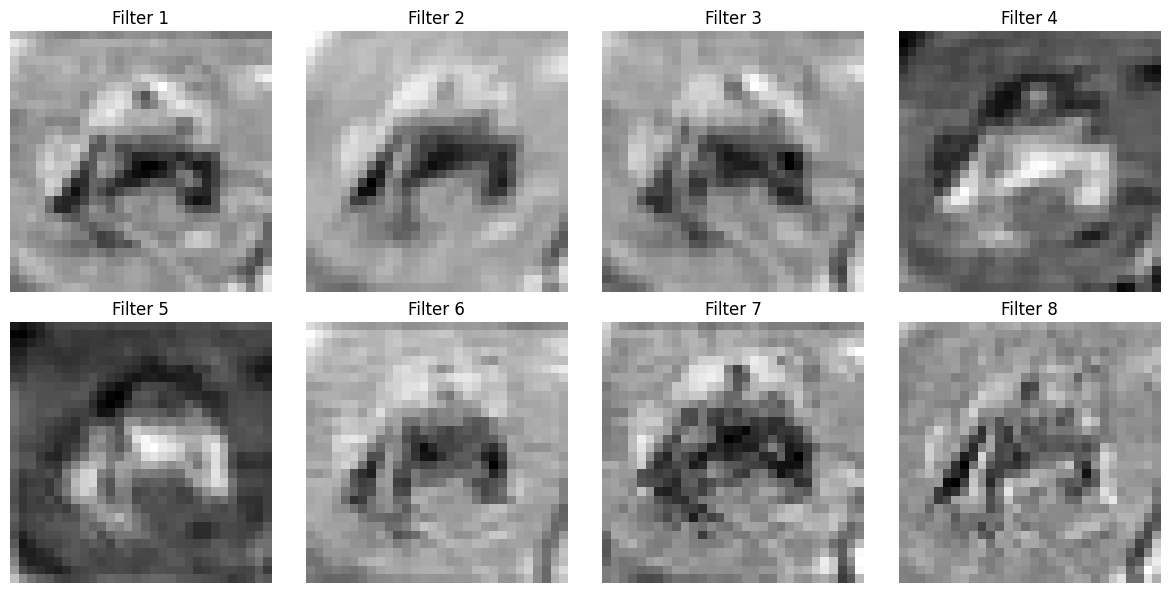

In [10]:
# CELL 9 — Exercise 27: Visualize the feature maps produced by the convolution

# Remove the batch dimension
feature_maps = y.squeeze(0).detach()

# Display all 8 feature maps
plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[i], cmap="gray")
    plt.axis("off")
    plt.title(f"Filter {i + 1}")

plt.tight_layout()
plt.show()

In [12]:
# CELL 10 — Exercise 28: Apply padding to preserve the image dimensions

# Create convolution with padding = 1
conv_padding = nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3,
    padding=1
)

# Apply convolution
y_padding = conv_padding(x)

print("Input shape:", x.shape)
print("Output shape with padding:", y_padding.shape)

Input shape: torch.Size([1, 3, 32, 32])
Output shape with padding: torch.Size([1, 8, 32, 32])


In [13]:
# CELL 11 — Exercise 29: Use stride = 2 to downsample the feature maps

# Create convolution with stride = 2
conv_stride = nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3,
    stride=2,
    padding=1
)

# Apply convolution
y_stride = conv_stride(x)

print("Input shape:", x.shape)
print("Output shape with stride = 2:", y_stride.shape)

Input shape: torch.Size([1, 3, 32, 32])
Output shape with stride = 2: torch.Size([1, 8, 16, 16])


In [14]:
# CELL 12 — Exercise 30: Apply the ReLU activation function

# Create ReLU
relu = nn.ReLU()

# Input containing negative and positive values
relu_input = torch.tensor([
    -5.,
    -2.,
     0.,
     2.,
     8.
])

# Apply ReLU
relu_output = relu(relu_input)

print("Input:")
print(relu_input)

print("\nOutput after ReLU:")
print(relu_output)

Input:
tensor([-5., -2.,  0.,  2.,  8.])

Output after ReLU:
tensor([0., 0., 0., 2., 8.])


In [15]:
# CELL 13 — Exercise 31: Apply 2 × 2 max pooling to a feature map

# Create the feature map from the module
pool_input = torch.tensor([
    [
        [
            [1., 2., 3., 4.],
            [5., 9., 7., 8.],
            [2., 3., 4., 1.],
            [8., 2., 1., 6.]
        ]
    ]
])

# Create max pooling layer
pool = nn.MaxPool2d(2)

# Apply max pooling
pool_output = pool(pool_input)

print("Input shape:", pool_input.shape)
print("Output shape:", pool_output.shape)

print("\nInput feature map:")
print(pool_input)

print("\nAfter Max Pooling:")
print(pool_output)

Input shape: torch.Size([1, 1, 4, 4])
Output shape: torch.Size([1, 1, 2, 2])

Input feature map:
tensor([[[[1., 2., 3., 4.],
          [5., 9., 7., 8.],
          [2., 3., 4., 1.],
          [8., 2., 1., 6.]]]])

After Max Pooling:
tensor([[[[9., 8.],
          [8., 6.]]]])


In [16]:
# CELL 14 — Exercise 32: Build a tiny CNN for CIFAR-10 classification

model = nn.Sequential(
    # First convolution block
    nn.Conv2d(3, 16, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Second convolution block
    nn.Conv2d(16, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Flatten feature maps
    nn.Flatten(),

    # CIFAR-10 has 10 classes
    nn.Linear(32 * 8 * 8, 10)
)

print(model)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=2048, out_features=10, bias=True)
)


In [17]:
# CELL 15 — Exercise 32: Trace the tensor shape after every layer of the Tiny CNN

# Start with one CIFAR-10 image
shape_x = image.unsqueeze(0)

print("Input:", shape_x.shape)

# First convolution
shape_x = model[0](shape_x)
print("After Conv2D:", shape_x.shape)

# ReLU
shape_x = model[1](shape_x)
print("After ReLU:", shape_x.shape)

# First pooling
shape_x = model[2](shape_x)
print("After MaxPool:", shape_x.shape)

# Second convolution
shape_x = model[3](shape_x)
print("After Conv2D:", shape_x.shape)

# ReLU
shape_x = model[4](shape_x)
print("After ReLU:", shape_x.shape)

# Second pooling
shape_x = model[5](shape_x)
print("After MaxPool:", shape_x.shape)

# Flatten
shape_x = model[6](shape_x)
print("After Flatten:", shape_x.shape)

# Final classification layer
shape_x = model[7](shape_x)
print("Final output:", shape_x.shape)

Input: torch.Size([1, 3, 32, 32])
After Conv2D: torch.Size([1, 16, 32, 32])
After ReLU: torch.Size([1, 16, 32, 32])
After MaxPool: torch.Size([1, 16, 16, 16])
After Conv2D: torch.Size([1, 32, 16, 16])
After ReLU: torch.Size([1, 32, 16, 16])
After MaxPool: torch.Size([1, 32, 8, 8])
After Flatten: torch.Size([1, 2048])
Final output: torch.Size([1, 10])


In [18]:
# CELL 16 — Exercise 33: Generate logits, probabilities, and predicted class

# Pass the CIFAR-10 image through the Tiny CNN
output = model(image.unsqueeze(0))

# Display raw logits
print("Raw logits:")
print(output)

print("\nLogits shape:")
print(output.shape)

# Convert logits to probabilities using Softmax
probabilities = torch.softmax(output, dim=1)

print("\nClass probabilities:")
print(probabilities)

# Find the class with the highest probability
predicted_class = torch.argmax(probabilities, dim=1).item()

print("\nPredicted class number:", predicted_class)
print("Predicted class:", classes[predicted_class])

print("\nActual class number:", label)
print("Actual class:", classes[label])

Raw logits:
tensor([[-0.0473,  0.0480,  0.0946,  0.0092, -0.0161, -0.0936,  0.0093,  0.0475,
          0.0058,  0.0192]], grad_fn=<AddmmBackward0>)

Logits shape:
torch.Size([1, 10])

Class probabilities:
tensor([[0.0945, 0.1040, 0.1090, 0.1000, 0.0975, 0.0903, 0.1000, 0.1039, 0.0997,
         0.1010]], grad_fn=<SoftmaxBackward0>)

Predicted class number: 2
Predicted class: bird

Actual class number: 6
Actual class: frog


In [19]:
# CELL 17 — Exercise 34: Demonstrate why accuracy can be misleading for imbalanced datasets

# Dataset information
normal = 950
defective = 50

# Model predicts NORMAL for every image
correct_predictions = 950

# Calculate accuracy
total = normal + defective
accuracy = correct_predictions / total

# Defective cases detected
defective_detected = 0

# Calculate recall
recall = defective_detected / defective

print("Normal cases:", normal)
print("Defective cases:", defective)

print("\nCorrect predictions:", correct_predictions)
print("Defective cases detected:", defective_detected)

print("\nAccuracy:", accuracy * 100, "%")
print("Recall for defective cases:", recall * 100, "%")

Normal cases: 950
Defective cases: 50

Correct predictions: 950
Defective cases detected: 0

Accuracy: 95.0 %
Recall for defective cases: 0.0 %


In [20]:
# CELL 18 — Exercise 35: Calculate and interpret the confusion matrix

from sklearn.metrics import confusion_matrix

# Actual labels
y_true = [1, 1, 1, 0, 0, 0]

# Predicted labels
y_pred = [1, 0, 1, 0, 0, 1]

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Extract values
TN, FP, FN, TP = cm.ravel()

print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

# Calculate precision and recall
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\nPrecision:", precision)
print("Recall:", recall)

Confusion Matrix:
[[2 1]
 [1 2]]

True Negative (TN): 2
False Positive (FP): 1
False Negative (FN): 1
True Positive (TP): 2

Precision: 0.6666666666666666
Recall: 0.6666666666666666


In [21]:
# CELL 19 — Exercise 36: Explain major CNN architectures and the problems they solved

architectures = {
    "LeNet":
        "Established the basic CNN approach using convolution, pooling, and fully connected layers for image recognition.",

    "AlexNet":
        "Demonstrated the effectiveness of deep CNNs using GPU training, ReLU activation, and large-scale image data.",

    "VGG":
        "Used repeated 3 × 3 convolution layers to create a deeper network with a simple and consistent architecture.",

    "Inception":
        "Used multiple kernel sizes and 1 × 1 convolutions to capture features at different scales while controlling computation.",

    "ResNet":
        "Used residual or skip connections to make very deep networks easier to train and reduce problems associated with network depth."
}

for name, explanation in architectures.items():
    print(f"\n{name}")
    print("-" * len(name))
    print(explanation)

print("\nResNet equation:")
print("y = F(x) + x")

print("\nPlain explanation:")
print("The network learns a transformation F(x) and adds the original input x to it.")


LeNet
-----
Established the basic CNN approach using convolution, pooling, and fully connected layers for image recognition.

AlexNet
-------
Demonstrated the effectiveness of deep CNNs using GPU training, ReLU activation, and large-scale image data.

VGG
---
Used repeated 3 × 3 convolution layers to create a deeper network with a simple and consistent architecture.

Inception
---------
Used multiple kernel sizes and 1 × 1 convolutions to capture features at different scales while controlling computation.

ResNet
------
Used residual or skip connections to make very deep networks easier to train and reduce problems associated with network depth.

ResNet equation:
y = F(x) + x

Plain explanation:
The network learns a transformation F(x) and adds the original input x to it.


In [22]:
# CELL 20 — Rapid Oral Evaluation: Key answers for Module 6 viva preparation

viva_answers = {
    "1. What does a kernel actually do?":
        "A kernel slides over an image and performs mathematical operations on local pixels to detect features such as edges, textures, and patterns.",

    "2. Why is augmentation not the same as collecting new data?":
        "Augmentation creates modified versions of existing images. It increases variation but does not provide genuinely new information from new real-world samples.",

    "3. Name one augmentation that can destroy labels and explain why.":
        "Vertical flipping can destroy labels when object orientation is important because the flipped image may not represent a realistic example of the same class.",

    "4. Why might a deterministic CV solution be preferable to a CNN?":
        "If a problem can be reliably solved using simple rules such as color, edges, or shape, deterministic computer vision can be cheaper, faster, and easier to interpret.",

    "5. What is the difference between a manually designed Sobel kernel and nn.Conv2d?":
        "A Sobel kernel has fixed, manually designed values, while nn.Conv2d contains learnable kernel values that are updated during neural-network training."
}

for question, answer in viva_answers.items():
    print("\n" + question)
    print("Answer:", answer)


1. What does a kernel actually do?
Answer: A kernel slides over an image and performs mathematical operations on local pixels to detect features such as edges, textures, and patterns.

2. Why is augmentation not the same as collecting new data?
Answer: Augmentation creates modified versions of existing images. It increases variation but does not provide genuinely new information from new real-world samples.

3. Name one augmentation that can destroy labels and explain why.
Answer: Vertical flipping can destroy labels when object orientation is important because the flipped image may not represent a realistic example of the same class.

4. Why might a deterministic CV solution be preferable to a CNN?
Answer: If a problem can be reliably solved using simple rules such as color, edges, or shape, deterministic computer vision can be cheaper, faster, and easier to interpret.

5. What is the difference between a manually designed Sobel kernel and nn.Conv2d?
Answer: A Sobel kernel has fixed,